In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [3]:
df = yf.download("^NSEI", start="2010-01-01")
print(df.tail())

[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2026-04-30  23997.550781  24087.449219  23796.849609  23996.949219  505500
2026-05-04  24119.300781  24290.199219  24004.750000  24063.550781  419100
2026-05-05  24032.800781  24081.699219  23882.050781  24052.599609  363300
2026-05-06  24330.949219  24356.500000  23997.900391  24171.000000  429200
2026-05-07  24326.650391  24482.099609  24284.000000  24398.500000  440600


In [4]:
df.columns = ["Close", "High", "Low", "Open", "Volume"]


count    4011.000000
mean        0.000438
std         0.010421
min        -0.129805
25%        -0.004835
50%         0.000588
75%         0.006111
max         0.087632
Name: return, dtype: float64

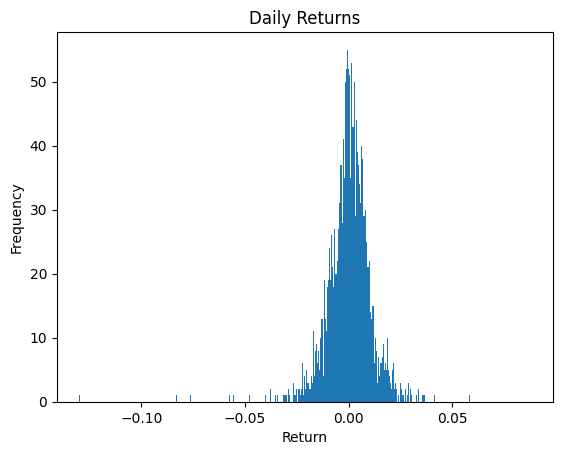

In [5]:
df["return"] = df["Close"]/df["Close"].shift(1) - 1
plt.hist(df["return"],bins=1000)
plt.title("Daily Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
df["return"].describe()



In [6]:
df_ohlc = df["Close"].resample("ME").ohlc()
df_ohlc.describe()

,open,high,low,close
count,197.000000,197.000000,197.000000,197.000000
mean,12094.045722,12448.636815,11776.948517,12165.960407
std,6452.775191,6604.364421,6323.140858,6476.624309
min,4765.299805,4931.850098,4544.200195,4624.299805
25%,6221.450195,6363.899902,6139.049805,6304.000000
50%,10211.799805,10471.000000,9998.049805,10302.099609
75%,17340.050781,17855.099609,16887.349609,17303.949219
max,26175.750000,26328.550781,25758.000000,26202.949219


In [7]:

df_std = df["return"].groupby(df.index.year).std() * (252**0.5)
print(df_std)
print(df_std.nlargest(5))

Date
2010    0.163200
2011    0.211865
2012    0.155362
2013    0.181721
2014    0.128097
2015    0.163531
2016    0.151947
2017    0.090289
2018    0.128838
2019    0.139415
2020    0.313290
2021    0.156535
2022    0.173275
2023    0.098153
2024    0.140640
2025    0.118111
2026    0.182542
Name: return, dtype: float64
Date
2020    0.313290
2011    0.211865
2026    0.182542
2013    0.181721
2022    0.173275
Name: return, dtype: float64


Date
2020-04-07    0.087632
2020-03-25    0.066247
2020-03-20    0.058329
2019-09-20    0.053191
2021-02-01    0.047424
Name: return, dtype: float64
Date
2020-03-23   -0.129805
2020-03-12   -0.083019
2020-03-16   -0.076121
2024-06-04   -0.059294
2015-08-24   -0.059151
Name: return, dtype: float64


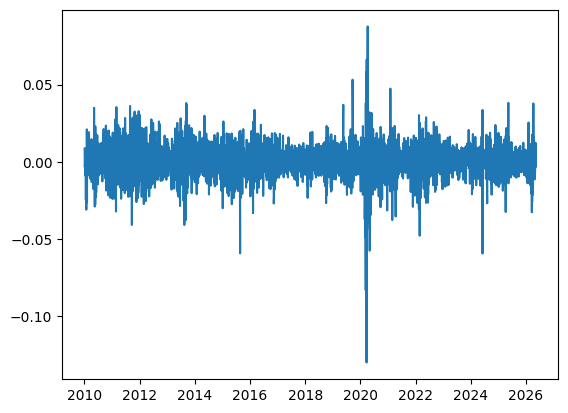

In [8]:
plt.plot(df.index, df["return"])
print(df["return"].nlargest(5))
print(df["return"].nsmallest(5))

#Observations:

1. biggest range in std was in year 2020 because of the covid pandemic.
2. anual std for each year sits around 0.15 but we have seen years with alot more than that 2020, 2011 and 2026 and its not over yet
3. It was amazing to see a simple 1% std becomes more than 15% annually thats a lot
4. it was surprsing to see that top 3 returns positive and negative to be in a single year of 2020


In [9]:
df_5yr = yf.download("^NSEI",end= "2026-05-05", start="2021-05-05")
df_5yr.columns = ['close', 'high', 'low', 'open', 'volume']
df_5yr['return'] = df_5yr['close'].pct_change()
df_5yr['actual_return'] = df_5yr['return'] * (1-0.02)
annual_return = 0.15


[*********************100%***********************]  1 of 1 completed


##Pull Nifty 50 data from yfinance. 5 years. Then:

1. Calculate daily returns
2. Estimate a realistic round-trip transaction cost — spread plus slippage — and justify your number
3. Show how many trading days per year a strategy would need to break even on costs alone if it targets 15% annual return
4. Plot annual volatility by year

[*********************100%***********************]  1 of 1 completed

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
max days for 15% return to break even = 150.0
      Volatility              Notes
Date                               
2021    0.122788     Standard Entry
2022    0.173275     Standard Entry
2023    0.098153     Standard Entry
2024    0.140640     Standard Entry
2025    0.118111     Standard Entry
2026    0.184392  Partial Year Data


Text(0.5, 1.0, 'Annual Volatility')

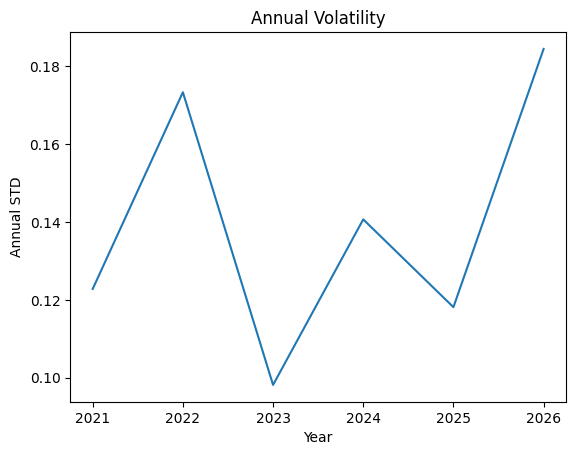

In [38]:
df_5yr = yf.download("^NSEI",end= "2026-05-05", start="2021-05-05")
df_5yr.columns = df_5yr.columns.droplevel(1)
print(df_5yr.columns)
df_5yr.columns = ['close', 'high', 'low', 'open', 'volume']
df_5yr['return'] = df_5yr['close'].pct_change() 

ret_gen = 0.15
round_trip_transaction_cost = 0.001
days = ret_gen/round_trip_transaction_cost
print(f'max days for 15% return to break even = {days}')
annual_vol = df_5yr['return'].groupby(df_5yr.index.year).std()*252**0.5
annual_vol = annual_vol.to_frame(name='Volatility')
annual_vol['Notes'] = 'Standard Entry'
annual_vol.at[2026, 'Notes'] = 'Partial Year Data' 
print(annual_vol)
plt.plot(annual_vol['Volatility'])
plt.xlabel("Year")
plt.ylabel("Annual STD")
plt.title("Annual Volatility")